# Active-set-aware parametric sensitivity

An advanced-step NMPC controller solves the next optimization ahead of
time, from the state it predicts the plant will reach, and holds the
solve's KKT factorization. When the measurement arrives, the controller
corrects the solution for the gap between the predicted and measured
state without solving again. `estimate()` is that correction. It
predicts the re-optimized trajectories from the held factorization.
This notebook is about what the correction does when a control sits at
a limit.

The model is a CSTR (Hicks & Ray 1971) with dimensionless concentration
`zc` and temperature `zt`, a coolant valve `v1` and a residence-time
valve `v2`, both piecewise constant over 100 one-minute sampling
intervals. The solve this notebook holds throughout starts at an upset,
`zc(0) = 0.5216` and `zt(0) = 0.4887`, cold and dilute against the
steady state at `(0.6416, 0.5387)`. The optimal response cuts cooling
to the valve's minimum and holds it there for the first stretch of the
horizon. That active bound is what makes the correction interesting:

1. a plain linear step predicts v1 below its minimum, values no plant
   can execute (`estimate_report` names exactly where that
   happens).
2. `mode="fix_relax"` repairs the prediction, holding v1 at the
   minimum on the intervals where it is saturated and letting the
   rest of the trajectory move consistently, and releasing
   those intervals when the measured state says the valve should
   come off its limit.
3. `mode="path"` applies the change from the predicted state to the
   measured one a little at a time, and
   reports where along the way the active set changes, which
   neither of the other modes can say.

Every experiment below has the same shape:

* the held solve, always the upset above.
* the measured state, one of the four cases in the table below.
* the prediction, one or more `estimate()` calls against the held
  factorization.
* the reference, a full re-solve at the measured state, warm-started
  from the held solution so it continues the same local solution.

All four measured states used below lie on the line from the held
initial state to the steady state:

| case | zc(0) | zt(0) | change in zc(0) | change in zt(0) | fraction of the way |
|---|---|---|---|---|---|
| A | 0.4916 | 0.4762 | -0.0300 | -0.0125 | -25% |
| B | 0.5516 | 0.5012 | +0.0300 | +0.0125 | +25% |
| C | 0.5816 | 0.5137 | +0.0600 | +0.0250 | +50% |
| D | 0.6416 | 0.5387 | +0.1200 | +0.0500 | +100% |

Each figure is titled with the case it uses. Case E, in section 8,
is the one exception to the held solve being the upset. It holds a
solve at the state 1.3% along the same line, where the record's
first entry says the active set changes, and takes a small measured
step from there.


In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pyomo.environ as pyo
from pyomo.dae import ContinuousSet, DerivativeVar

import pyomo_pounce  # registers 'pounce' with SolverFactory
from pyomo_cvp import declare_profile
from pyomo_pounce import declare_sens_param, estimate, estimate_report

ZC_SS, ZT_SS = 0.6416, 0.5387      # the steady state the cost tracks
V1_SS, V2_SS = 0.57828, 0.49989
N, H = 100, 1                      # 100 sampling intervals of 1 minute
V1_MIN = 1 / 6                     # the coolant valve's lower limit


def build(zc0, zt0):
    m = pyo.ConcreteModel()
    m.t = ContinuousSet(initialize=pyo.RangeSet(0, N * H, H))

    m.u1sf = pyo.Param(initialize=600)    # coolant-flow scale factor
    m.u2sf = pyo.Param(initialize=40)     # residence-time scale factor
    m.k0 = pyo.Param(initialize=300)      # Arrhenius pre-exponential
    m.ea = pyo.Param(initialize=5)        # dimensionless activation energy
    m.a0 = pyo.Param(initialize=1.95e-4)  # heat-transfer coefficient
    m.ztcw = pyo.Param(initialize=0.38)   # coolant temperature
    m.ztf = pyo.Param(initialize=0.395)   # feed temperature

    m.zc_ss = pyo.Param(initialize=ZC_SS)
    m.zt_ss = pyo.Param(initialize=ZT_SS)
    m.v1_ss = pyo.Param(initialize=V1_SS)
    m.v2_ss = pyo.Param(initialize=V2_SS)

    # the initial condition, and the two sensitivity parameters
    m.zc0 = pyo.Param(initialize=zc0, mutable=True)
    m.zt0 = pyo.Param(initialize=zt0, mutable=True)

    m.zc = pyo.Var(m.t, bounds=(0, 1), initialize=ZC_SS)
    m.zt = pyo.Var(m.t, bounds=(0, None), initialize=ZT_SS)
    m.dzc = DerivativeVar(m.zc, wrt=m.t)
    m.dzt = DerivativeVar(m.zt, wrt=m.t)
    m.v1 = pyo.Var(m.t, bounds=(V1_MIN, 1), initialize=V1_SS)
    m.v2 = pyo.Var(m.t, bounds=(0.025, 1), initialize=V2_SS)
    declare_profile(m.v1, m.v2, wrt=m.t, profile="piecewise_constant")

    @m.Constraint(m.t)
    def zc_ode(m, t):
        return m.dzc[t] == (1 - m.zc[t]) / (m.u2sf * m.v2[t]) - m.k0 * m.zc[t] * pyo.exp(-m.ea / m.zt[t])

    @m.Constraint(m.t)
    def zt_ode(m, t):
        return m.dzt[t] == (m.ztf - m.zt[t]) / (m.u2sf * m.v2[t]) + m.k0 * m.zc[t] * pyo.exp(-m.ea / m.zt[t]) - m.a0 * m.u1sf * m.v1[t] * (m.zt[t] - m.ztcw)

    @m.Constraint()
    def zc_init(m):
        return m.zc[0] == m.zc0

    @m.Constraint()
    def zt_init(m):
        return m.zt[0] == m.zt0

    grid = sorted(m.t)

    @m.Objective()
    def obj(m):
        return sum(
            10 * (m.zc[t] - m.zc_ss) ** 2 + 2 * (m.zt[t] - m.zt_ss) ** 2
            + (m.v1[t] - m.v1_ss) ** 2 + 0.5 * (m.v2[t] - m.v2_ss) ** 2
            for t in grid[:-1]) + 1000 * (10 * (m.zc[grid[-1]] - m.zc_ss) ** 2 + 2 * (m.zt[grid[-1]] - m.zt_ss) ** 2)

    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
    pyo.TransformationFactory("cvp.parameterize").apply_to(m)
    declare_sens_param(m.zc0)
    declare_sens_param(m.zt0)
    return m


def solve(m, tee=False):
    res = pyo.SolverFactory("pounce").solve(m, tee=tee,
                                            options={"tol": 1e-8})
    assert str(res.solver.termination_condition) == "optimal"
    return m


# the base case starts at an upset, colder and more dilute than the target
BASE = (ZC_SS - 0.12, ZT_SS - 0.05)
base = solve(build(*BASE))

def v1_profile(m, source=None):
    keys = sorted(k for k, _ in m.v1.items())
    if source is None:
        vals = [pyo.value(m.v1[k]) for k in keys]
    else:
        vals = [source[m.v1[k]] for k in keys]
    return np.asarray(keys, float), np.asarray(vals, float)

def state_profile(m, var, source=None):
    keys = sorted(m.t)
    if source is None:
        vals = [pyo.value(var[k]) for k in keys]
    else:
        vals = [source[var[k]] for k in keys]
    return np.asarray(keys, float), np.asarray(vals, float)

tk, v1b = v1_profile(base)
sat = v1b < V1_MIN + 1e-4
print(f"valve v1 at its minimum for {sat.sum()} of {len(v1b)} intervals "
      f"(the first {sat[:int(sat.sum()) + 2].sum()} of the horizon)")


def v2_profile(m, source=None):
    keys = sorted(k for k, _ in m.v2.items())
    if source is None:
        vals = [pyo.value(m.v2[k]) for k in keys]
    else:
        vals = [source[m.v2[k]] for k in keys]
    return np.asarray(keys, float), np.asarray(vals, float)


def panels(entries, xlim=40, v1_extra=None, title=None):
    """One 2x2 figure: both states on top, both valves below.

    entries: (label, model, est, kwargs). est is None to read the
    model's own values, or an estimate() result read on the base
    model's variables.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for label, m, est, kw in entries:
        t, zc = state_profile(m, m.zc, est)
        axes[0, 0].plot(t, zc, label=label, **kw)
        t, zt = state_profile(m, m.zt, est)
        axes[0, 1].plot(t, zt, label=label, **kw)
        t, v1 = v1_profile(m, est)
        axes[1, 0].step(t, v1, where="post", label=label, **kw)
        t, v2 = v2_profile(m, est)
        axes[1, 1].step(t, v2, where="post", label=label, **kw)
    if v1_extra is not None:
        t, v, lab = v1_extra
        axes[1, 0].step(t, v, where="post", color="tab:orange", lw=1,
                        ls=":", label=lab)
    axes[1, 0].axhline(V1_MIN, color="crimson", lw=1, ls="--")
    for ax, name in zip(axes.flat, ("zc, concentration", "zt, temperature",
                                    "v1, coolant valve",
                                    "v2, residence-time valve")):
        ax.set_title(name)
        ax.set_xlim(0, xlim)
    for ax in axes[1]:
        ax.set_xlabel("time (min)")
    axes[0, 0].legend(fontsize=8)
    if title is not None:
        fig.suptitle(title)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    plt.show()


valve v1 at its minimum for 13 of 100 intervals (the first 13 of the horizon)


## 1. The base solution

With the reactor cold, the controller cuts cooling to the valve's
minimum and holds it there, letting the exotherm reheat the
reactor, then eases cooling back in as the state approaches the
target. The shaded band is the stretch where `v1` sits
at its minimum, which is the active set this notebook is about.


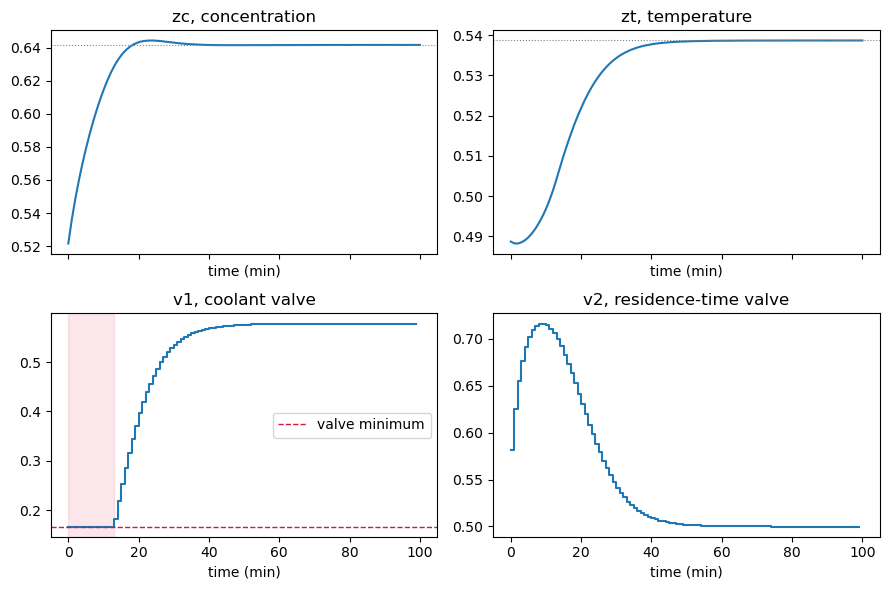

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
for ax, (var, ss, name) in zip(
        axes.flat[:2],
        [(base.zc, ZC_SS, "zc, concentration"),
         (base.zt, ZT_SS, "zt, temperature")]):
    t, x = state_profile(base, var)
    ax.plot(t, x)
    ax.axhline(ss, color="gray", lw=0.8, ls=":")
    ax.set_title(name)
ax = axes.flat[2]
ax.step(tk, v1b, where="post")
ax.axhline(V1_MIN, color="crimson", lw=1, ls="--", label="valve minimum")
on = np.where(sat)[0]
if on.size:
    ax.axvspan(tk[on[0]], tk[on[-1]] + H, color="crimson", alpha=0.10)
ax.set_title("v1, coolant valve")
ax.legend()
ax = axes.flat[3]
tk2, v2b = ( np.asarray(sorted(k for k, _ in base.v2.items()), float),
             np.asarray([pyo.value(base.v2[k]) for k in
                         sorted(k for k, _ in base.v2.items())], float))
ax.step(tk2, v2b, where="post")
ax.set_title("v2, residence-time valve")
for ax in axes.flat:
    ax.set_xlabel("time (min)")
fig.tight_layout()
plt.show()


## 2. The measured state is farther from the steady state than predicted

* prediction: `estimate(mode="linear", clamp=True)`, the baseline a
  caller gets without choosing anything
* reference: re-solve at the measured state

The linear step treats v1 in every sampling interval as free to
move, including the 13 intervals where it sits at the minimum. With
`clamp=False` the prediction crosses below the valve minimum (the
thin dotted trace). With `clamp=True` those
values are pulled back to the minimum, so the valve plot looks
plausible. The error is in everything else. Every other predicted
value was computed as though the valve really had gone below its
minimum, so the temperature trajectory that comes with the clamped
v1 values is inconsistent with them. The clamp hides the problem in
the valve plot and moves it into the states.


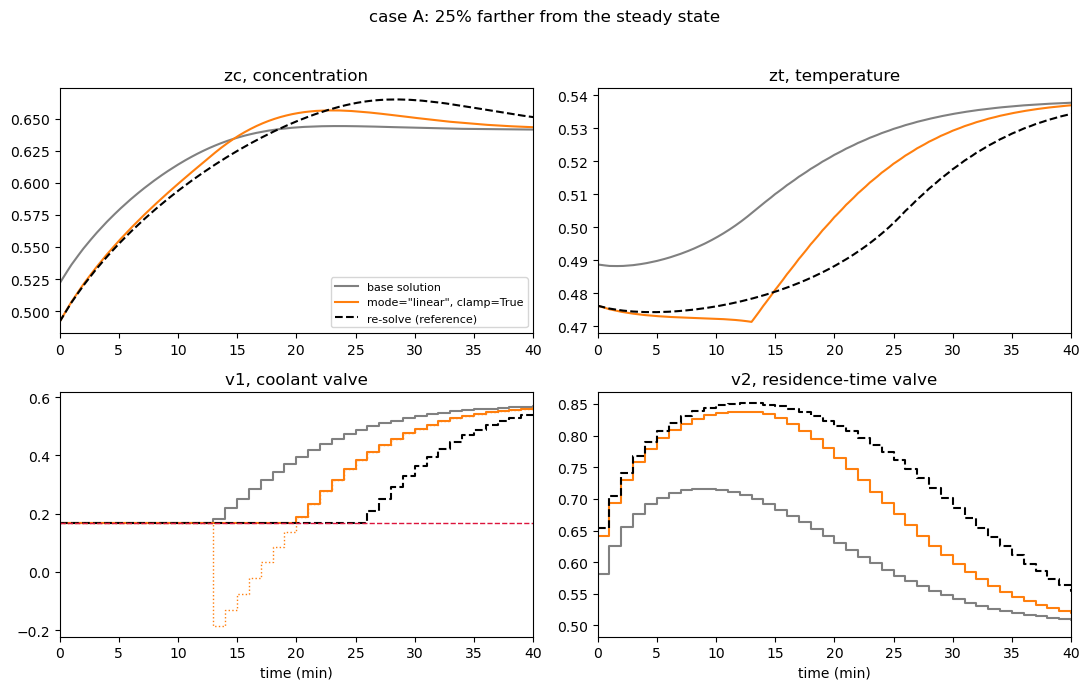

with clamp=False the step predicts v1 below its minimum on 8 intervals, by up to 0.3508. clamp=True pulls them back to the minimum


In [3]:
def warm_resolve(zc0, zt0):
    m = build(zc0, zt0)
    seed = {v.name: pyo.value(v, exception=False)
            for v in base.component_data_objects(pyo.Var, active=True)}
    for v in m.component_data_objects(pyo.Var, active=True):
        sv = seed.get(v.name)
        if sv is not None:
            v.set_value(sv, skip_validation=True)
    return solve(m)

WORSE = (BASE[0] - 0.03, BASE[1] - 0.0125)   # 25% farther out
truth_worse = warm_resolve(*WORSE)
perturb_worse = [(base.zc0, WORSE[0]), (base.zt0, WORSE[1])]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_lin = estimate(base, perturb_worse)               # clamp=True
    est_open = estimate(base, perturb_worse, clamp=False)

_, v1_open = v1_profile(base, est_open)
panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True', base, est_lin, dict(color="tab:orange")),
    ("re-solve (reference)", truth_worse, None,
     dict(color="black", ls="--")),
], v1_extra=(tk, v1_open, 'mode="linear", clamp=False'), title='case A: 25% farther from the steady state')

below = v1_open < V1_MIN - 1e-6
print(f"with clamp=False the step predicts v1 below its minimum on "
      f"{below.sum()} intervals, by up to "
      f"{(V1_MIN - v1_open[below]).max():.4f}. clamp=True pulls them "
      "back to the minimum")


`estimate_report()` measures this without fixing it. It runs the same step and reports the first bound crossing:
which variable, which bound, and the fraction of the step at
which the crossing happens. A fraction well below 1 says the
linear prediction is only trustworthy for a fraction of the gap between
predicted and measured state.


In [4]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rep = estimate_report(base, [(base.zc0, WORSE[0]),
                                 (base.zt0, WORSE[1])])
print(rep)


EstimateReport(alpha=0.0434554, first variable v1[13], crossed=20, violation=1.125e-03, mu=2.506e-09)


## 3. Repairing the prediction: `mode="fix_relax"`

* prediction: `estimate(mode="fix_relax")`
* reference: the same re-solve

Where the clamp forces each crossing v1 value back to the minimum
and leaves every other value untouched, `mode="fix_relax"` pins the
crossing v1 value at the minimum and re-solves the system with that
pin, so every other prediction moves consistently with the valve actually
sitting at its limit. This is sIPOPT's fix-relax, run against the same
held factorization.

The number printed under each figure from here on is the
prediction's largest error. Every value of the four predicted
trajectories is compared with the re-solve's value, the difference
is divided by that value (floored at 0.01 so values near zero do
not inflate the ratio), and the largest result is reported. An
error of 0.01 means the worst predicted value is 1% away from the
re-solve's.


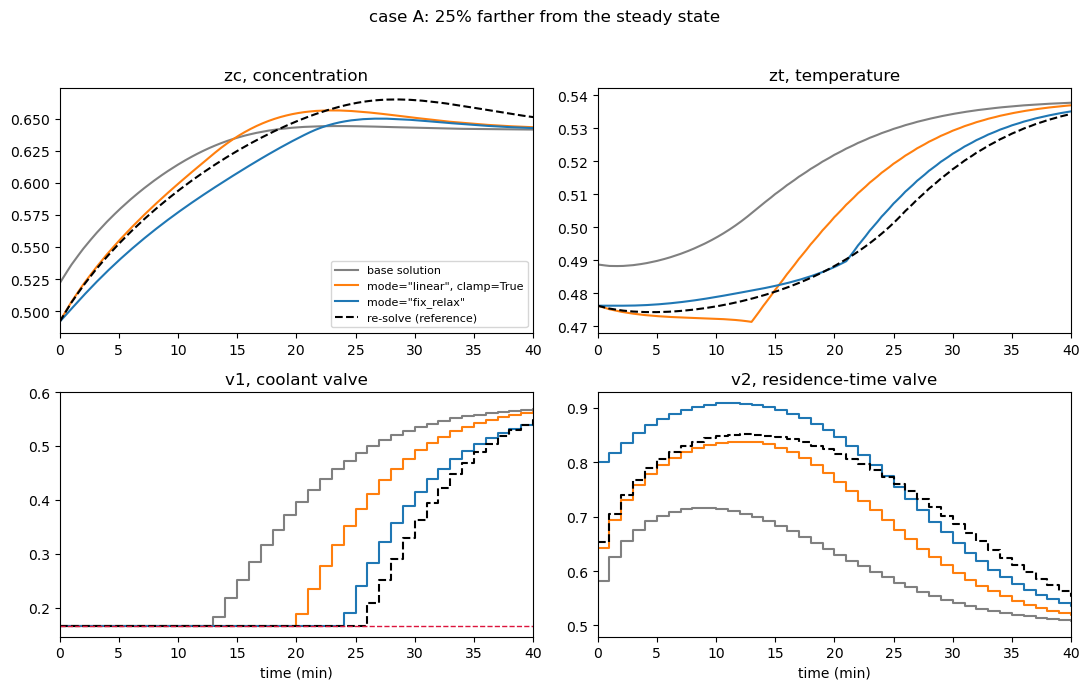

largest error, mode="linear", clamp=True: 1.301
largest error, mode="fix_relax":    0.436


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_fr = estimate(base, perturb_worse, mode="fix_relax", max_iter=60)

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True', base, est_lin, dict(color="tab:orange")),
    ('mode="fix_relax"', base, est_fr, dict(color="tab:blue")),
    ("re-solve (reference)", truth_worse, None,
     dict(color="black", ls="--")),
], title='case A: 25% farther from the steady state')

def worst_err(est, truth_m):
    truth = {v.name: pyo.value(v, exception=False)
             for v in truth_m.component_data_objects(pyo.Var, active=True)}
    w = 0.0
    for vd, val in est.items():
        tv = truth.get(vd.name)
        if tv is None or not vd.name.startswith(("zc[", "zt[", "v1[", "v2[")):
            continue
        w = max(w, abs(val - tv) / max(abs(tv), 1e-2))
    return w

print(f'largest error, mode="linear", clamp=True: '
      f"{worst_err(est_lin, truth_worse):.3f}")
print(f'largest error, mode="fix_relax":    '
      f"{worst_err(est_fr, truth_worse):.3f}")


## 4. The measured state is nearer the steady state than predicted

* predictions: `estimate(mode="linear", clamp=True)` and
  `estimate(mode="fix_relax")`
* reference: re-solve at the measured state, which takes the valve off
  its minimum over most of the saturated stretch

This direction needs the opposite repair. A linear step preserves
complementarity, so a v1 value at its minimum stays exactly there
however far the measured state moves. The `mode="linear"` prediction
is stuck, and the clamp has nothing to do because no bound is
crossed. `mode="fix_relax"` checks the bound multipliers instead,
releases each bound whose multiplier the step drives negative, and
lets v1 move there.


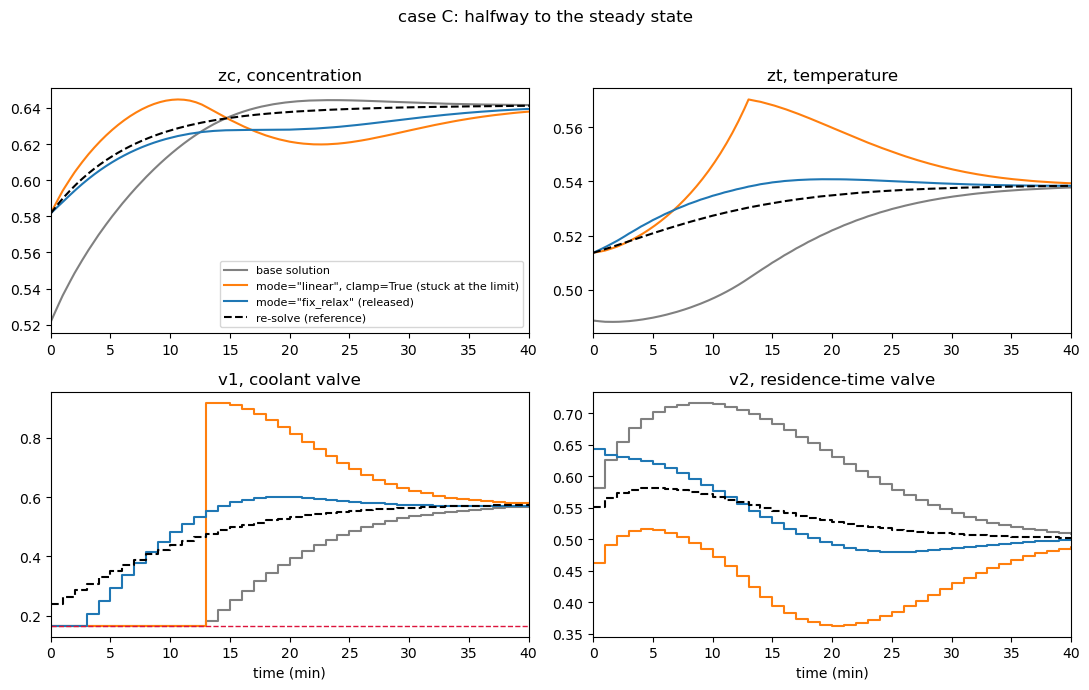

largest error, mode="linear", clamp=True: 0.920
largest error, mode="fix_relax":    0.417


In [6]:
HALF = (BASE[0] + 0.06, BASE[1] + 0.025)
truth_half = warm_resolve(*HALF)
perturb_half = [(base.zc0, HALF[0]), (base.zt0, HALF[1])]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_lin_h = estimate(base, perturb_half)
    est_fr_h = estimate(base, perturb_half, mode="fix_relax", max_iter=60)

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True (stuck at the limit)', base, est_lin_h,
     dict(color="tab:orange")),
    ('mode="fix_relax" (released)', base, est_fr_h,
     dict(color="tab:blue")),
    ("re-solve (reference)", truth_half, None,
     dict(color="black", ls="--")),
], title='case C: halfway to the steady state')

print(f'largest error, mode="linear", clamp=True: '
      f"{worst_err(est_lin_h, truth_half):.3f}")
print(f'largest error, mode="fix_relax":    '
      f"{worst_err(est_fr_h, truth_half):.3f}")


## 5. What `mode="path"` adds: the record of active-set changes

* predictions: `estimate(mode="fix_relax")` and `estimate(mode="path")`
* reference: re-solve at the measured state

`mode="path"` applies the change a little at a time instead of all at
once, and every time v1 reaches its minimum on some interval or leaves
it, it records the fraction of the change at which that happened. The
trajectories it predicts coincide with `mode="fix_relax"`'s at this
change, so the figure draws the fix_relax line wider with the path
line on top of it. The record is the part no
other mode produces, printed after the figure. v1 leaves its minimum
interval by interval, from minute 12 backward, and the first change
comes after about 1% of the change. That first fraction is how much
measurement discrepancy leaves the held solve's active set unchanged.


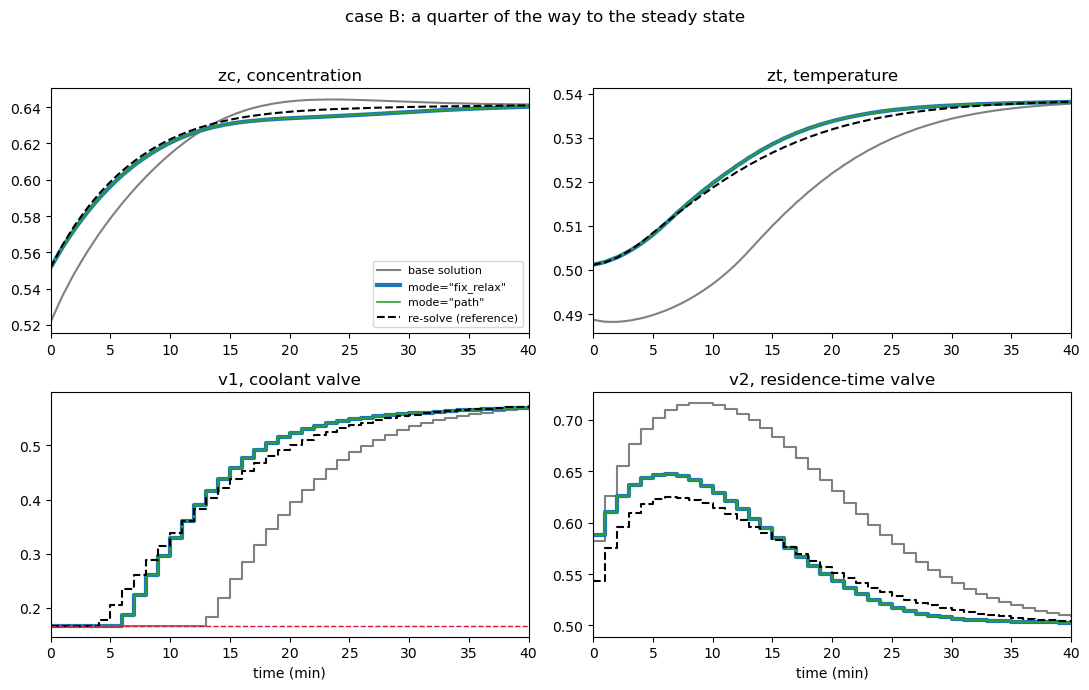

largest error, mode="fix_relax": 0.199
largest error, mode="path":      0.199

the record, over the full change to the steady state:
interval (min)   fraction of the change at which v1 leaves its minimum
      12                0.013
      11                0.039
      10                0.068
       9                0.099
       8                0.134
       7                0.175
       6                0.221
       5                0.275
       4                0.340
       3                0.419
       2                0.518
       1                0.646
       0                0.819


In [7]:
from pyomo_pounce import active_set_changes

FULL = (ZC_SS, ZT_SS)

# the record, taken over the full change to the steady state
perturb_full = [(base.zc0, FULL[0]), (base.zt0, FULL[1])]
record = active_set_changes(base, perturb_full, max_iter=60)

# re-solves along the way (also used below)
fracs = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
sweep_truth = {}
for f in fracs:
    tgt = (BASE[0] + f * (FULL[0] - BASE[0]),
           BASE[1] + f * (FULL[1] - BASE[1]))
    sweep_truth[f] = warm_resolve(*tgt)

# the experiment at case B
Q = 0.25
QTGT = (BASE[0] + Q * (FULL[0] - BASE[0]), BASE[1] + Q * (FULL[1] - BASE[1]))
truth_q = sweep_truth[Q]
perturb_q = [(base.zc0, QTGT[0]), (base.zt0, QTGT[1])]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_fr_q = estimate(base, perturb_q, mode="fix_relax", max_iter=60)
    est_path_q = estimate(base, perturb_q, mode="path", max_iter=60)

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="fix_relax"', base, est_fr_q, dict(color="tab:blue", lw=3)),
    ('mode="path"', base, est_path_q, dict(color="tab:green", lw=1.2)),
    ("re-solve (reference)", truth_q, None, dict(color="black", ls="--")),
], title='case B: a quarter of the way to the steady state')

print(f"largest error, mode=\"fix_relax\": "
      f"{worst_err(est_fr_q, truth_q):.3f}")
print(f"largest error, mode=\"path\":      "
      f"{worst_err(est_path_q, truth_q):.3f}")

print("\nthe record, over the full change to the steady state:")
print("interval (min)   fraction of the change at which v1 leaves its minimum")
for c in record:
    assert c.action == "leaves" and c.bound == "lower"
    print(f"      {int(c.var.index()):2d}                {c.fraction:.3f}")


The same comparison at the full change is the regime where the order
reverses.

* predictions: all three modes
* reference: re-solve at the measured state

At this size all 13 intervals leave the minimum. `mode="fix_relax"`
decides all 13 releases at once, from the multipliers of a single step
taken at the base point, and its one re-solve overshoots. Its
prediction lands below even `mode="linear"`. `mode="path"` applies each
release at the fraction the record names and is the most accurate of
the three. The panels also show what any
first-order prediction looks like at a change this large. Even the
best mode misses parts of the trajectories badly.


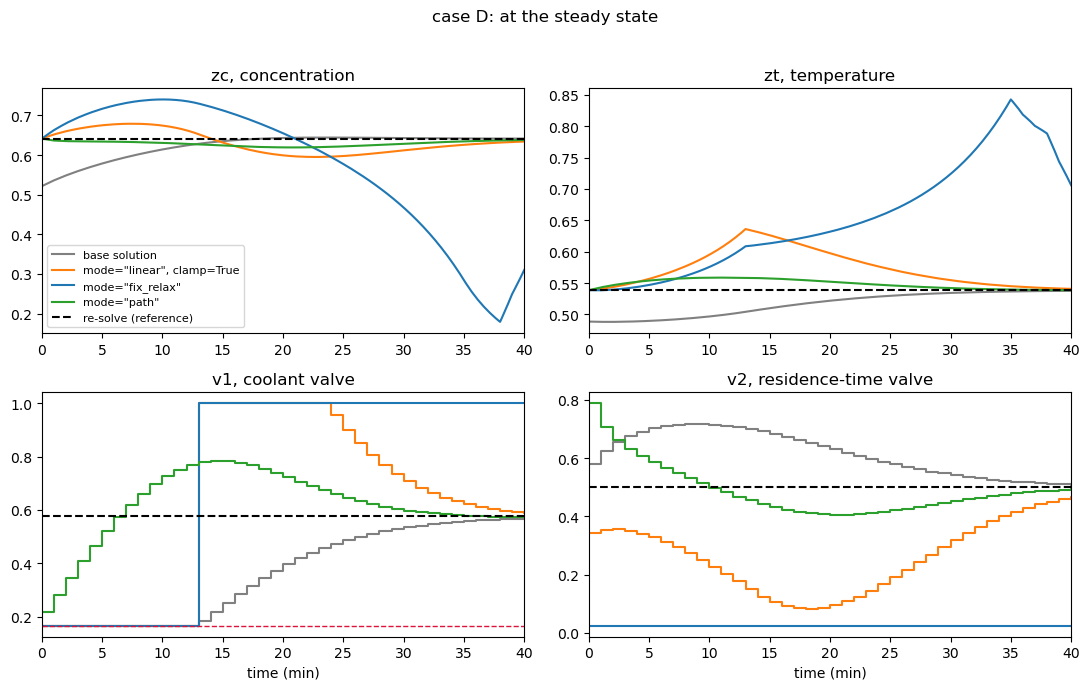

largest error, mode="linear", clamp=True: 0.833
largest error, mode="fix_relax":          0.950
largest error, mode="path":               0.626
mode="path" used 13 of the max_iter=60 allowed changes


In [8]:
FULLTGT = sweep_truth[1.0]
perturb_f = [(base.zc0, FULL[0]), (base.zt0, FULL[1])]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est_lin_f = estimate(base, perturb_f)
    est_fr_f = estimate(base, perturb_f, mode="fix_relax", max_iter=60)
    est_path_f = estimate(base, perturb_f, mode="path", max_iter=60)

panels([
    ("base solution", base, None, dict(color="gray")),
    ('mode="linear", clamp=True', base, est_lin_f, dict(color="tab:orange")),
    ('mode="fix_relax"', base, est_fr_f, dict(color="tab:blue")),
    ('mode="path"', base, est_path_f, dict(color="tab:green")),
    ("re-solve (reference)", FULLTGT, None, dict(color="black", ls="--")),
], title='case D: at the steady state')

print(f'largest error, mode="linear", clamp=True: '
      f"{worst_err(est_lin_f, FULLTGT):.3f}")
print(f'largest error, mode="fix_relax":          '
      f"{worst_err(est_fr_f, FULLTGT):.3f}")
print(f'largest error, mode="path":               '
      f"{worst_err(est_path_f, FULLTGT):.3f}")
print(f'mode="path" used {len(record)} of the max_iter=60 allowed changes')


## 6. The effect of `max_iter` on `mode="fix_relax"`

The sweep runs at the smaller of the two changes in section 5,
where the two modes reach the same accuracy.

* predictions: `estimate(mode="fix_relax")` at `max_iter` of 1, 2,
  4, 8, and 16
* reference: re-solve at the measured state

`max_iter` caps how many active-set changes the prediction may
apply, and the changes not applied are handled by the clamp, with a
warning. The second figure plots the wall time of the `estimate()` call
against the cap, with the re-solve's own time as the dashed line. Times are the best of three repeats on this
machine.


re-solve wall time at this measured state: 1.30 s


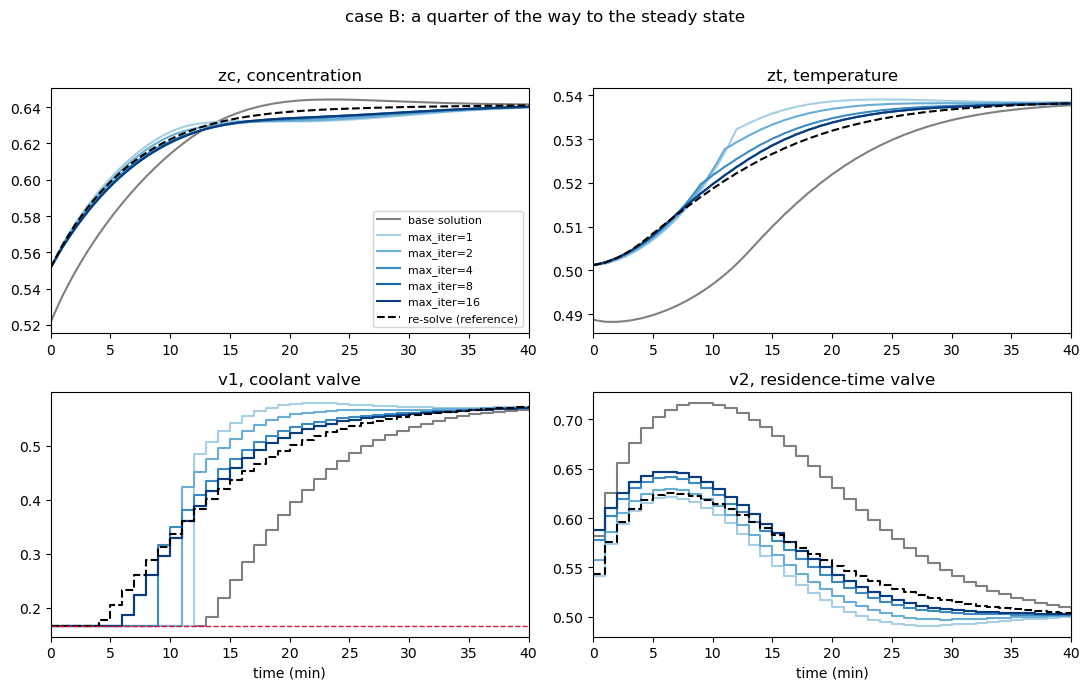

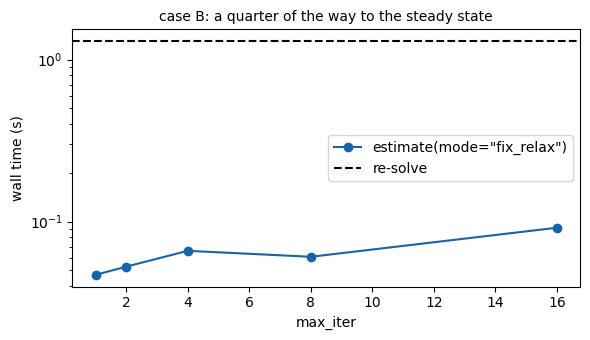

  max_iter= 1   largest error 0.538   wall time    46.9 ms
  max_iter= 2   largest error 0.506   wall time    52.8 ms
  max_iter= 4   largest error 0.420   wall time    66.0 ms
  max_iter= 8   largest error 0.199   wall time    60.7 ms
  max_iter=16   largest error 0.199   wall time    91.7 ms


In [9]:
import time as _time

MAXITERS = [1, 2, 4, 8, 16]
GRADS = {"fix_relax": cm.Blues, "path": cm.Greens}


def timed_estimate(mode, perturb, k, reps=3):
    best, est = None, None
    for _ in range(reps):
        t0 = _time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            est = estimate(base, perturb, mode=mode, max_iter=k)
        dt = _time.perf_counter() - t0
        best = dt if best is None else min(best, dt)
    return est, best


def maxiter_figures(mode, perturb, truth, t_resolve, title=None):
    cmap = GRADS[mode]
    ests, times = {}, {}
    for k in MAXITERS:
        ests[k], times[k] = timed_estimate(mode, perturb, k)
    entries = [("base solution", base, None, dict(color="gray"))]
    for j, k in enumerate(MAXITERS):
        shade = cmap(0.35 + 0.6 * j / (len(MAXITERS) - 1))
        entries.append((f"max_iter={k}", base, ests[k], dict(color=shade)))
    entries.append(("re-solve (reference)", truth, None,
                    dict(color="black", ls="--")))
    panels(entries, title=title)
    plt.figure(figsize=(6, 3.5))
    plt.plot(MAXITERS, [times[k] for k in MAXITERS], "o-",
             color=cmap(0.8), label=f'estimate(mode="{mode}")')
    plt.axhline(t_resolve, color="black", ls="--", label="re-solve")
    plt.yscale("log")
    plt.xlabel("max_iter")
    plt.ylabel("wall time (s)")
    if title is not None:
        plt.title(title, fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()
    for k in MAXITERS:
        print(f"  max_iter={k:2d}   largest error "
              f"{worst_err(ests[k], truth):.3f}   "
              f"wall time {times[k]*1e3:7.1f} ms")


t0 = _time.perf_counter()
_ = warm_resolve(*QTGT)
T_RES_Q = _time.perf_counter() - t0
print(f"re-solve wall time at this measured state: {T_RES_Q:.2f} s")
maxiter_figures("fix_relax", perturb_q, truth_q, T_RES_Q,
                title='case B: a quarter of the way to the steady state')


## 7. The effect of `max_iter` on `mode="path"`

The sweep runs at the larger change, where this mode was the more
accurate and all 13 intervals of v1 leave the minimum.

* predictions: `estimate(mode="path")` at `max_iter` of 1, 2, 4,
  8, and 16
* reference: re-solve at the measured state

A capped call applies the first `max_iter` recorded changes and
takes the rest of the change in one step under the active set it
reached. On the cost side, each release re-factors the KKT system
with that bound's diagonal term removed, so the wall time grows
about linearly with the number of releases applied, and stays well
below the re-solve.


re-solve wall time at this measured state: 1.00 s


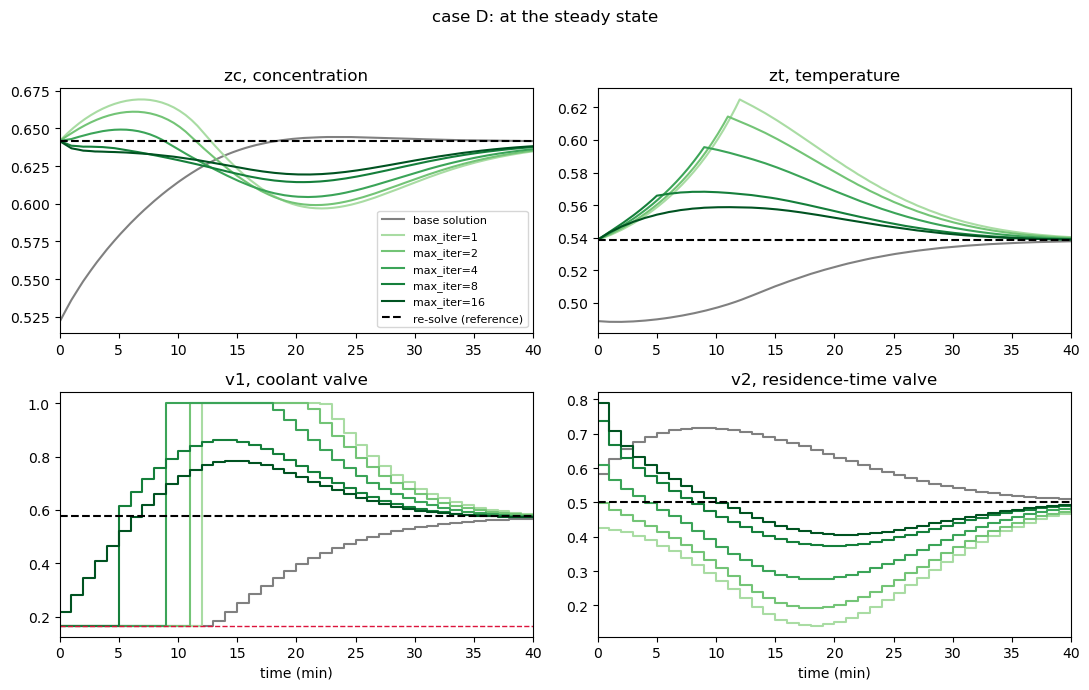

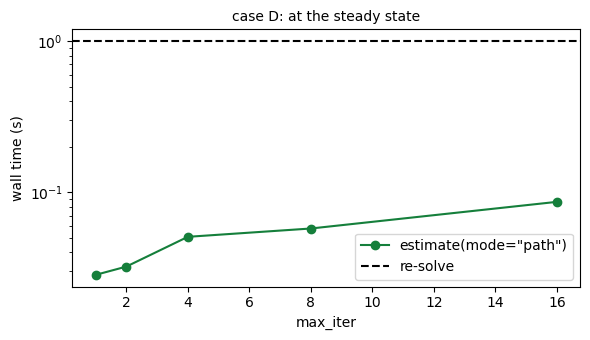

  max_iter= 1   largest error 0.729   wall time    28.4 ms
  max_iter= 2   largest error 0.729   wall time    32.3 ms
  max_iter= 4   largest error 0.729   wall time    50.7 ms
  max_iter= 8   largest error 0.712   wall time    57.6 ms
  max_iter=16   largest error 0.626   wall time    86.4 ms


In [10]:
t0 = _time.perf_counter()
_ = warm_resolve(*FULL)
T_RES_F = _time.perf_counter() - t0
print(f"re-solve wall time at this measured state: {T_RES_F:.2f} s")
maxiter_figures("path", perturb_f, FULLTGT, T_RES_F, title='case D: at the steady state')


## 8. A held solve at the record's first breakpoint: `degeneracy`

The record in section 5 names the state where v1's interval 12 leaves
its minimum, 1.3% of the way from the upset to the steady state. This
section holds a solve at that state. Interval 12 sits on its
minimum with a multiplier of the same order as the slack, the activity
classifier declines to call the bound active or inactive, and
`gradient()` warns that its value is one-sided. The solution has a
kink there. Toward the steady state the bound releases, away from it
the bound holds, and no single linear step is right for both sides.

* held solve: (0.5232, 0.4894), the record's first breakpoint
* measured state: (0.5256, 0.4904), 2% of the full change further
  toward the steady state
* predictions: all three modes, under `degeneracy="one_sided"` in the
  left column and `degeneracy="directional"` in the right
* reference: re-solve at the measured state

`degeneracy` selects what happens at such a base point. `"one_sided"`
takes the single-sided value the complementarity split produces
(active when the multiplier exceeds the slack). Here the split
classifies the bound as
inactive, so `mode="path"` cannot release it and degrades to the
linear step. Its largest error is 0.0077 and its record is
empty. Linear
and path are identical in the left column, so the figure draws the
linear line widest with the path line on top. `mode="fix_relax"`
reaches 0.0018, but not by construction. Its release test reads a
sign from the uncorrected step at a point where the true multiplier
is exactly zero, and on this model the read comes out right.

`"directional"` (the default) decides the bound for the
perturbation's own direction by the directional derivative QP (the
sIPOPT paper's eq. 14) on the held factorization. All three modes
land at 0.0018. For fix_relax that is the same number as before, but
the release decision now comes from the QP instead of the sign read,
so what was a favorable read is now guaranteed. The record says
v1[12] leaves its minimum at fraction 0.008, the zero crossing of
the residual multiplier the solve left.

At a step this small the curves coincide at full scale, so the figure
shows v1 alone, zoomed to the intervals around the kink, and the
printed table carries the comparison over all variables.


In [11]:
from pyomo_pounce import estimate_report, gradient

F1 = record[0].fraction
E = (BASE[0] + F1 * (FULL[0] - BASE[0]), BASE[1] + F1 * (FULL[1] - BASE[1]))
ETGT = (E[0] + 0.02 * (FULL[0] - BASE[0]), E[1] + 0.02 * (FULL[1] - BASE[1]))
held_e = warm_resolve(*E)
perturb_e = [(held_e.zc0, ETGT[0]), (held_e.zt0, ETGT[1])]

print(f"the record's first entry: {record[0].var.name} leaves its "
      f"{record[0].bound} bound at fraction {F1:.4f}")
print("classifier at this held solve: v1[12] is "
      f"{estimate_report(held_e, perturb_e).activity['v1[12]']}")
# The warning below is gradient()'s. With no direction to choose a
# side, it names the degenerate bound and refers the caller to
# estimate().
g12 = gradient(held_e.find_component("v1[12]"), wrt=held_e.zc0)
print(f"gradient(v1[12], wrt=zc0) = {g12:.4f}, one side's value")


the record's first entry: v1[12] leaves its lower bound at fraction 0.0132
classifier at this held solve: v1[12] is ambiguous
gradient(v1[12], wrt=zc0) = 2.8458, one side's value


C:\Users\Devin\dev\pounce-upstream\pyomo-pounce\pyomo_pounce\sens.py:1091: UserWarning: gradient: the base point is degenerate: ['v1[12] (lower)'] sit on a bound with a multiplier of the same order as the slack, so the solution has two one-sided derivatives there and this value is one side's. estimate() computes the directional derivative for the perturbation it is given.
  warnings.warn(


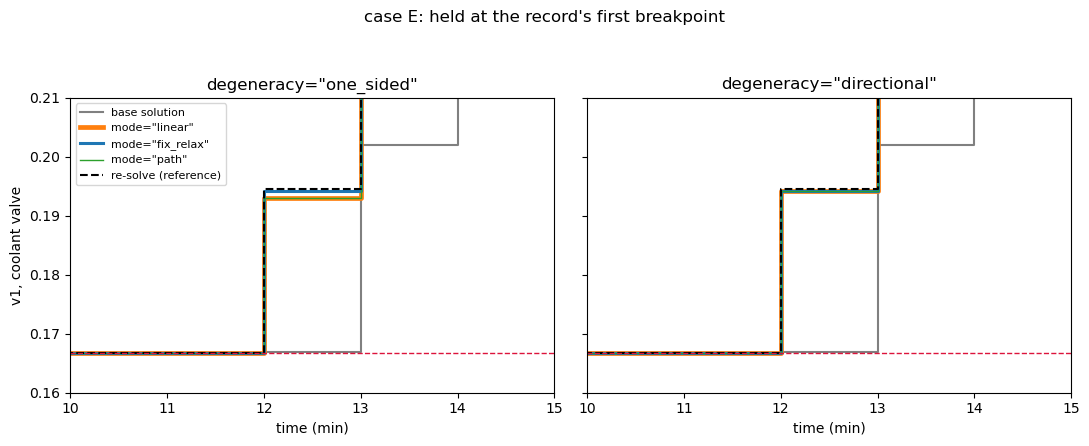

degeneracy="one_sided", mode="linear":  largest error 0.0077
degeneracy="one_sided", mode="fix_relax":  largest error 0.0018
degeneracy="one_sided", mode="path":  largest error 0.0077
degeneracy="directional", mode="linear":  largest error 0.0018
degeneracy="directional", mode="fix_relax":  largest error 0.0018
degeneracy="directional", mode="path":  largest error 0.0018
record under "one_sided": empty
record under "directional": [('v1[12]', 'lower', 'leaves', 0.008)]


In [12]:
truth_e = warm_resolve(*ETGT)
ests = {}
for deg in ("one_sided", "directional"):
    for mode in ("linear", "fix_relax", "path"):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ests[deg, mode] = estimate(held_e, perturb_e, mode=mode,
                                       max_iter=60, degeneracy=deg)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
t_truth, v1_truth = v1_profile(truth_e)
for ax, deg in zip(axes, ("one_sided", "directional")):
    series = [
        ("base solution", held_e, None, dict(color="gray")),
        ('mode="linear"', held_e, ests[deg, "linear"],
         dict(color="tab:orange", lw=3.4)),
        ('mode="fix_relax"', held_e, ests[deg, "fix_relax"],
         dict(color="tab:blue", lw=2.2)),
        ('mode="path"', held_e, ests[deg, "path"],
         dict(color="tab:green", lw=1.0)),
    ]
    for label, mm, e, kw in series:
        t_, v_ = v1_profile(mm, e)
        ax.step(t_, v_, where="post", label=label, **kw)
    ax.step(t_truth, v1_truth, where="post", color="black", ls="--",
            label="re-solve (reference)")
    ax.axhline(V1_MIN, color="crimson", lw=1, ls="--")
    ax.set_xlim(10, 15)
    ax.set_ylim(0.160, 0.210)
    ax.set_title(f'degeneracy="{deg}"')
    ax.set_xlabel("time (min)")
axes[0].set_ylabel("v1, coolant valve")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("case E: held at the record's first breakpoint")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

for deg in ("one_sided", "directional"):
    for mode in ("linear", "fix_relax", "path"):
        print(f'degeneracy="{deg}", mode="{mode}":  largest error '
              f"{worst_err(ests[deg, mode], truth_e):.4f}")
for deg in ("one_sided", "directional"):
    ch = active_set_changes(held_e, perturb_e, max_iter=60, degeneracy=deg)
    shown = ([(c.var.name, c.bound, c.action, round(c.fraction, 3))
              for c in ch] or "empty")
    print(f'record under "{deg}": {shown}')
